In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

sns.set_style("whitegrid")


In [2]:
df = pd.read_csv(r"D:\AI\poly\housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.dropna(inplace=True)

In [5]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

## Exploratory Data Analysis

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


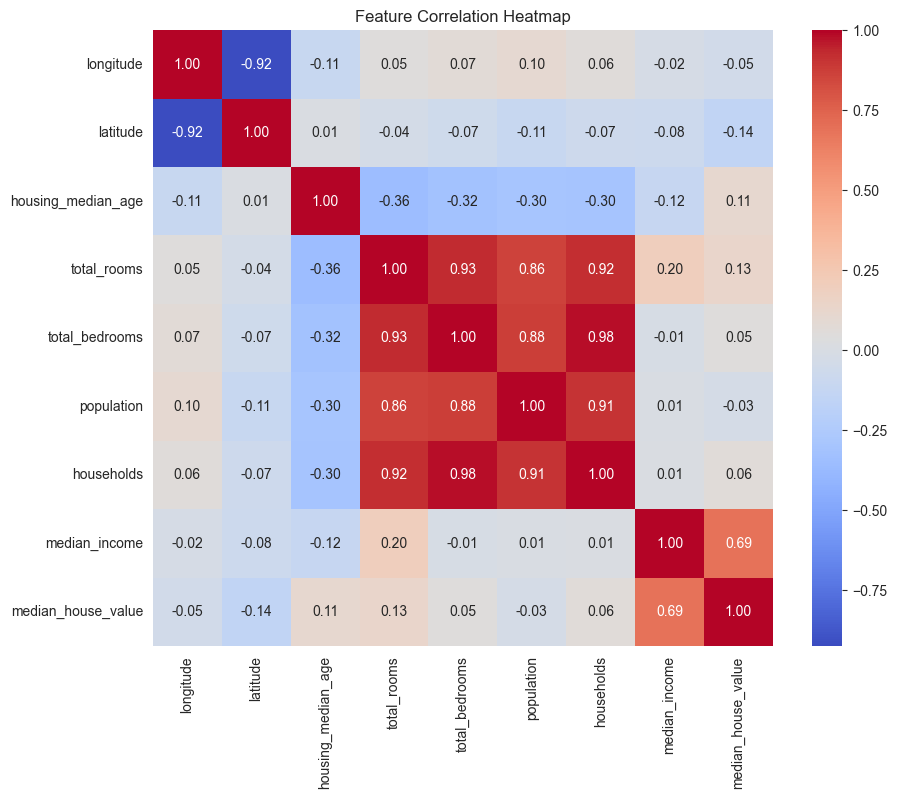

In [7]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

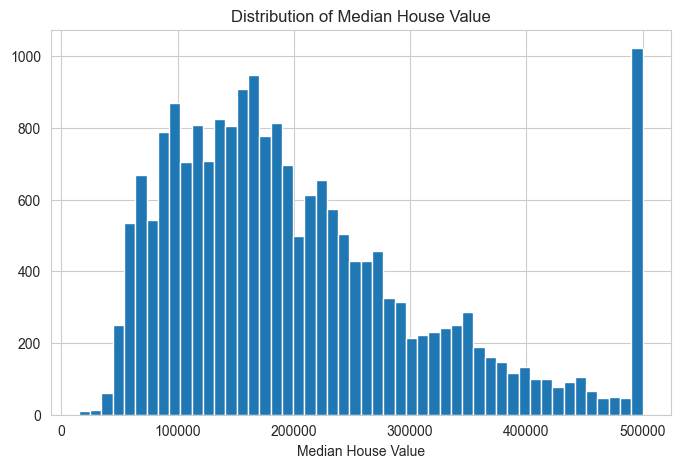

In [8]:
df["median_house_value"].hist(bins=50, figsize=(8, 5))
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.show()

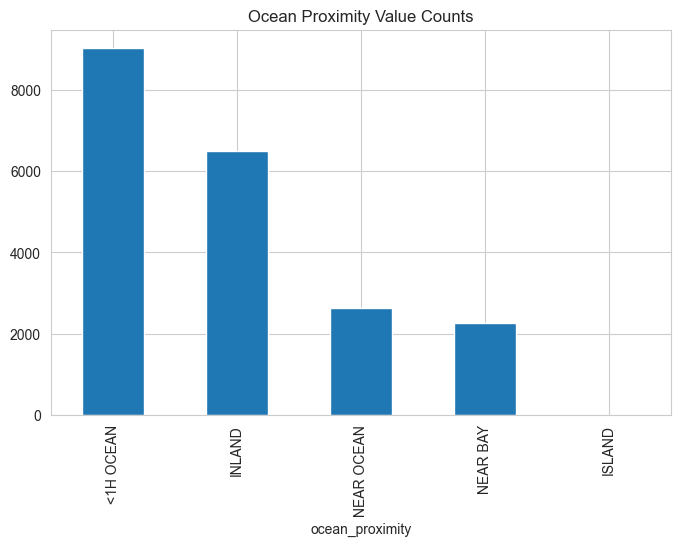

In [9]:
df["ocean_proximity"].value_counts().plot(kind="bar", figsize=(8, 5))
plt.title("Ocean Proximity Value Counts")
plt.show()

## Feature Engineering

Add ratio features that are well known to correlate with price in this dataset (raw room/population counts matter less than per-household ratios), and one-hot encode the categorical `ocean_proximity` column.

In [10]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,False,False,True,False


In [11]:
X = df.drop(columns=["median_house_value"])
y = df["median_house_value"]

## Train/Test Split & Scaling

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Distance/gradient-based models (KNN, SVR) need scaled features;
# tree-based models are unaffected by scaling but it doesn't hurt them.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## Train & Compare Common Regression Algorithms

`median_house_value` is continuous, so this is a regression problem — each candidate is scored with R² (higher is better), MAE, and RMSE (both in dollars, lower is better).

In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(kernel="rbf", C=10),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)

    results[name] = {
        "R2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
    }
    print(f"{name:20s}  R2={results[name]['R2']:.4f}  MAE={results[name]['MAE']:,.0f}  RMSE={results[name]['RMSE']:,.0f}")

Linear Regression     R2=0.6514  MAE=49,775  RMSE=69,043
Ridge Regression      R2=0.6514  MAE=49,774  RMSE=69,042


Lasso Regression      R2=0.6514  MAE=49,774  RMSE=69,043


KNN Regressor         R2=0.7255  MAE=40,822  RMSE=61,264


SVR                   R2=0.0128  MAE=85,964  RMSE=116,192


Decision Tree         R2=0.6642  MAE=43,006  RMSE=67,770


Random Forest         R2=0.8132  MAE=32,752  RMSE=50,536


Gradient Boosting     R2=0.7853  MAE=37,203  RMSE=54,189


In [14]:
results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
results_df

,R2,MAE,RMSE
Random Forest,0.813250,32751.514476,50535.538810
Gradient Boosting,0.785272,37202.936404,54188.988050
KNN Regressor,0.725539,40821.772400,61264.244372
Decision Tree,0.664154,43006.302422,67769.864234
Ridge Regression,0.651424,49773.621342,69042.314762
Lasso Regression,0.651419,49774.471398,69042.775400
Linear Regression,0.651419,49774.505370,69042.799689
SVR,0.012765,85964.482837,116192.141783


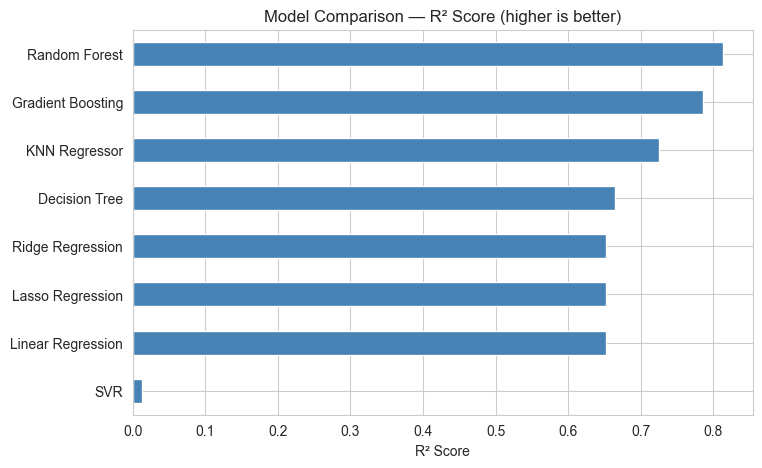

In [15]:
results_df["R2"].plot(kind="barh", figsize=(8, 5), color="steelblue")
plt.title("Model Comparison — R² Score (higher is better)")
plt.xlabel("R² Score")
plt.gca().invert_yaxis()
plt.show()

## Hyperparameter Tuning the Best Model

Tree-based ensembles (Random Forest / Gradient Boosting) usually win on this dataset since price depends on non-linear interactions between location and income. Tune Random Forest with `RandomizedSearchCV`.

In [16]:
param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train_s, y_train)

print("Best params:", rf_search.best_params_)
best_model = rf_search.best_estimator_
pred = best_model.predict(X_test_s)

print("Tuned Random Forest R2:", r2_score(y_test, pred))
print("Tuned Random Forest MAE:", mean_absolute_error(y_test, pred))
print("Tuned Random Forest RMSE:", mean_squared_error(y_test, pred) ** 0.5)

Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Tuned Random Forest R2: 0.8190669177858726
Tuned Random Forest MAE: 33259.37078338465
Tuned Random Forest RMSE: 49742.261804779286


## Feature Importance

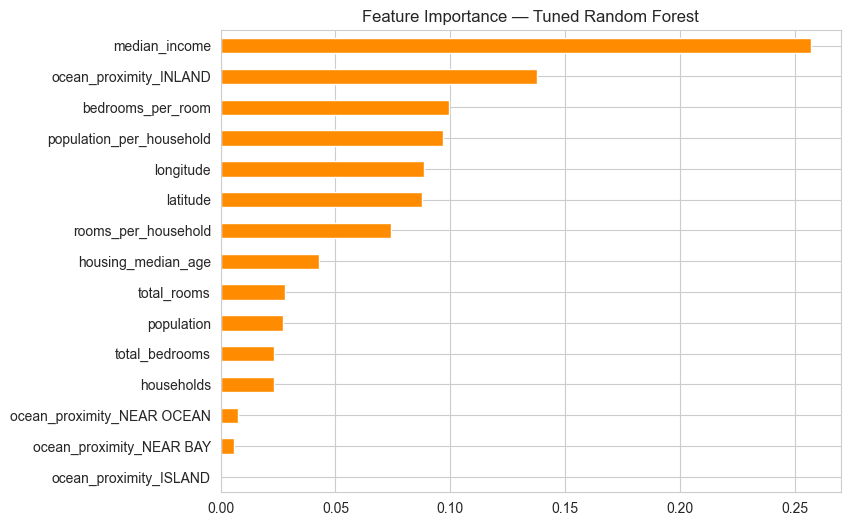

In [17]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

importances.plot(kind="barh", figsize=(8, 6), color="darkorange")
plt.title("Feature Importance — Tuned Random Forest")
plt.gca().invert_yaxis()
plt.show()

## Conclusion

Tree-based ensembles (Random Forest, Gradient Boosting) substantially outperform linear and distance-based models on this dataset, because house price depends on non-linear interactions between location and income rather than a simple linear combination of features. `median_income` and the location/ratio-derived features (`rooms_per_household`, latitude/longitude) are consistently the strongest predictors. The tuned Random Forest above is the best model found.